# Ruptura integrator benchmark analysis

This notebook analyzes both performance and numerical outcomes for the generated benchmark matrix. It reports live run status, runtime scaling and paired speedups, then compares the actual breakthrough curves using overlays, breakthrough times, and curve-error metrics.

It is safe to rerun while the benchmark array is progressing. SIRK3 remains visible in coverage tables but is excluded from runnable summaries until successful results exist.

## Setup and live result loading

Paths resolve automatically from either the repository root or the benchmark directory. Only the tail of each run log is read, so large logs do not need to fit in memory.

In [18]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:.6g}")


def locate_benchmark_directory() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if candidate.name == "benchmark" and (candidate / "manifest.csv").is_file():
            return candidate
        nested = candidate / "benchmark"
        if (nested / "manifest.csv").is_file():
            return nested
    raise FileNotFoundError("Could not locate benchmark/manifest.csv")


BENCHMARK_DIR = locate_benchmark_directory()
MANIFEST_PATH = BENCHMARK_DIR / "manifest.csv"
RESULTS_PATH = BENCHMARK_DIR / "results.csv"
print(f"Benchmark directory: {BENCHMARK_DIR}")


Benchmark directory: /Users/youriran/pusan/ruptura/benchmark


In [19]:
manifest = pd.read_csv(MANIFEST_PATH)
for column in ("grid_points", "time_step", "axial_dispersion_coefficient"):
    manifest[column] = pd.to_numeric(manifest[column])

if RESULTS_PATH.is_file() and RESULTS_PATH.stat().st_size:
    try:
        results = pd.read_csv(RESULTS_PATH)
    except pd.errors.EmptyDataError:
        results = pd.DataFrame(columns=["directory", "return_code", "elapsed_seconds"])
else:
    results = pd.DataFrame(columns=["directory", "return_code", "elapsed_seconds"])

results = results.drop_duplicates("directory", keep="last")
for column in ("return_code", "elapsed_seconds"):
    results[column] = pd.to_numeric(results[column], errors="coerce")

TOTAL_TIME_RE = re.compile(r"Total time:\s+([0-9.eE+-]+) s")
FINAL_STEP_RE = re.compile(r"Final timestep (\d+), time:\s*([0-9.eE+-]+) \[s\]")


def log_tail(path: Path, byte_count: int = 262_144) -> str:
    if not path.is_file():
        return ""
    with path.open("rb") as stream:
        stream.seek(0, 2)
        stream.seek(max(0, stream.tell() - byte_count))
        return stream.read().decode("utf-8", errors="replace")


def read_log_metrics(relative_directory: str) -> dict:
    path = BENCHMARK_DIR / relative_directory / "run.log"
    text = log_tail(path)
    total_matches = TOTAL_TIME_RE.findall(text)
    final_matches = FINAL_STEP_RE.findall(text)
    return {
        "directory": relative_directory,
        "has_log": path.is_file(),
        "solver_seconds": float(total_matches[-1]) if total_matches else np.nan,
        "final_steps": int(final_matches[-1][0]) if final_matches else np.nan,
        "final_simulated_seconds": float(final_matches[-1][1]) if final_matches else np.nan,
    }


log_metrics = pd.DataFrame(
    read_log_metrics(directory) for directory in manifest["directory"]
)
runs = (
    manifest
    .merge(results, on="directory", how="left")
    .merge(log_metrics, on="directory", how="left")
)
runs["runnable_now"] = runs["integrator"].isin(["rk3", "cvode"])
runs["status"] = np.select(
    [
        runs["return_code"].eq(0),
        runs["return_code"].notna(),
        runs["solver_seconds"].notna(),
        runs["has_log"],
    ],
    ["success", "failed", "complete/unindexed", "running or interrupted"],
    default="pending",
)

print(f"Manifest configurations: {len(manifest):,}")
print(f"Indexed results: {len(results):,}")
print(f"Run logs present: {int(runs['has_log'].sum()):,}")


Manifest configurations: 315
Indexed results: 210
Run logs present: 210


## Matrix coverage and current status

In [20]:
matrix_coverage = (
    manifest.groupby(["base_case", "integrator"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["rk3", "cvode", "sirk3"])
)
status_coverage = (
    runs.groupby(["base_case", "integrator", "status"], observed=True)
    .size()
    .unstack(fill_value=0)
)

display(matrix_coverage.style.set_caption("Generated configurations"))
display(status_coverage.style.set_caption("Current run status"))

runnable = runs[runs["runnable_now"]]
successful_count = int(runnable["status"].eq("success").sum())
failed_count = int(runnable["status"].eq("failed").sum())
print(
    f"Runnable progress: {successful_count}/{len(runnable)} successful, "
    f"{failed_count} failed"
)


integrator,rk3,cvode,sirk3
base_case,,,
bea-alkanes-C7,105,105,105


Runnable progress: 210/210 successful, 0 failed


## Timing and scaling

Wall time comes from the runner and includes startup and output overhead. Solver time is parsed from each completed Ruptura log. Every timing run advances the model over the same 0.1-second physical horizon, and the runtime curves below use the median across dispersion coefficients.

runs  median_wall_seconds  min_wall_seconds  \
base_case      integrator                                                
bea-alkanes-C7 cvode        105              4.81079          0.036315   
               rk3          105             0.058904          0.014489   

                           max_wall_seconds  median_solver_seconds  \
base_case      integrator                                            
bea-alkanes-C7 cvode                333.208                4.79042   
               rk3                  2.18696               0.032169   

                           median_final_simulated_seconds  
base_case      integrator                                  
bea-alkanes-C7 cvode                                  0.1  
               rk3                                    0.1

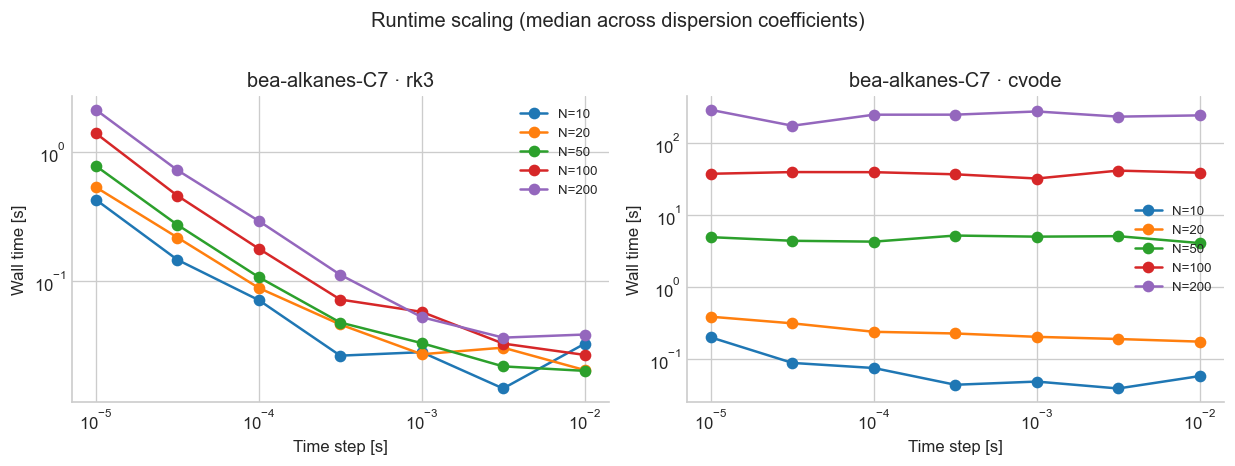

In [21]:
successful = runs[
    runs["return_code"].eq(0) & runs["elapsed_seconds"].notna()
].copy()

if successful.empty:
    print("No successful indexed runs yet. Rerun this cell as results arrive.")
else:
    runtime_summary = (
        successful.groupby(["base_case", "integrator"], observed=True)
        .agg(
            runs=("directory", "size"),
            median_wall_seconds=("elapsed_seconds", "median"),
            min_wall_seconds=("elapsed_seconds", "min"),
            max_wall_seconds=("elapsed_seconds", "max"),
            median_solver_seconds=("solver_seconds", "median"),
            median_final_simulated_seconds=("final_simulated_seconds", "median"),
        )
    )
    display(runtime_summary)

    cases = list(successful["base_case"].drop_duplicates())
    integrators = [
        name for name in ("rk3", "cvode", "sirk3")
        if name in set(successful["integrator"])
    ]
    fig, axes = plt.subplots(
        len(cases),
        len(integrators),
        figsize=(5.2 * len(integrators), 3.8 * len(cases)),
        squeeze=False,
    )
    for row, case in enumerate(cases):
        for column, integrator in enumerate(integrators):
            axis = axes[row, column]
            subset = successful[
                (successful["base_case"] == case)
                & (successful["integrator"] == integrator)
            ]
            medians = (
                subset.groupby(
                    ["grid_points", "time_step"], observed=True
                )["elapsed_seconds"]
                .median()
                .reset_index()
            )
            for grid_points, values in medians.groupby("grid_points"):
                values = values.sort_values("time_step")
                axis.plot(
                    values["time_step"],
                    values["elapsed_seconds"],
                    marker="o",
                    label=f"N={grid_points}",
                )
            axis.set_xscale("log")
            axis.set_yscale("log")
            axis.set_title(f"{case} · {integrator}")
            axis.set_xlabel("Time step [s]")
            axis.set_ylabel("Wall time [s]")
            if not medians.empty:
                axis.legend(fontsize=8)
    fig.suptitle(
        "Runtime scaling (median across dispersion coefficients)", y=1.01
    )
    fig.tight_layout()
    plt.show()


## Paired RK3/CVODE speedup

Only exact parameter matches are paired. A ratio above one means CVODE completed faster than RK3.

,paired_runs,median,min,max
base_case,,,,
bea-alkanes-C7,105,0.0252127,0.00013413,2.15883


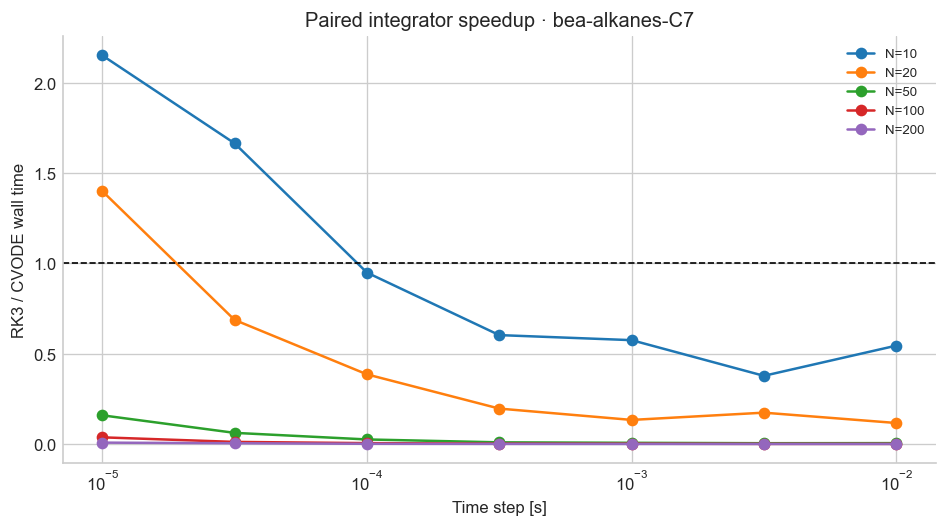

In [22]:
pair_keys = [
    "base_case",
    "grid_points",
    "time_step",
    "axial_dispersion_coefficient",
]
wall_pivot = successful.pivot_table(
    index=pair_keys,
    columns="integrator",
    values="elapsed_seconds",
    aggfunc="last",
)

if not {"rk3", "cvode"}.issubset(wall_pivot.columns):
    paired_timing = pd.DataFrame()
    print("No completed RK3/CVODE timing pairs yet.")
else:
    paired_timing = (
        wall_pivot.dropna(subset=["rk3", "cvode"]).reset_index()
    )
    paired_timing["rk3_over_cvode"] = (
        paired_timing["rk3"] / paired_timing["cvode"]
    )
    display(
        paired_timing.groupby("base_case")["rk3_over_cvode"]
        .agg(["count", "median", "min", "max"])
        .rename(columns={"count": "paired_runs"})
    )

    for case, case_data in paired_timing.groupby("base_case"):
        fig, axis = plt.subplots(figsize=(8, 4.5))
        grouped = (
            case_data.groupby(
                ["grid_points", "time_step"], observed=True
            )["rk3_over_cvode"]
            .median()
            .reset_index()
        )
        for grid_points, values in grouped.groupby("grid_points"):
            values = values.sort_values("time_step")
            axis.plot(
                values["time_step"],
                values["rk3_over_cvode"],
                marker="o",
                label=f"N={grid_points}",
            )
        axis.axhline(1.0, color="black", linewidth=1, linestyle="--")
        axis.set_xscale("log")
        axis.set_xlabel("Time step [s]")
        axis.set_ylabel("RK3 / CVODE wall time")
        axis.set_title(f"Paired integrator speedup · {case}")
        axis.legend(fontsize=8)
        fig.tight_layout()
        plt.show()


## Breakthrough-curve reader and outcome metrics

Ruptura output files can become large for small timesteps. The reader below processes them in chunks and retains only the column-outlet rows. Curves are cached within this kernel after their first use.

Outcome metrics include the first times the normalized outlet pressure reaches 10%, 50%, and 90%, plus RMSE and maximum absolute difference on a common interpolated time grid.

In [23]:
COLUMN_RE = re.compile(r"# column (\d+): (.*)")
CURVE_CACHE: dict[tuple[str, int], tuple[str, pd.DataFrame]] = {}


def output_column_index(path: Path, label_fragment: str) -> int:
    with path.open(encoding="utf-8", errors="replace") as stream:
        for line in stream:
            if not line.startswith("#"):
                break
            match = COLUMN_RE.match(line.strip())
            if (
                match
                and label_fragment.casefold() in match.group(2).casefold()
            ):
                return int(match.group(1)) - 1
    raise ValueError(
        f"Column containing {label_fragment!r} not found in {path}"
    )


def load_outlet_curve(
    directory: Path,
    component_index: int,
    chunksize: int = 200_000,
) -> tuple[str, pd.DataFrame]:
    cache_key = (str(directory), component_index)
    if cache_key in CURVE_CACHE:
        return CURVE_CACHE[cache_key]

    files = sorted(
        directory.glob(f"component_{component_index}_*.data")
    )
    if not files:
        raise FileNotFoundError(
            f"No component {component_index} output in {directory}"
        )

    path = files[0]
    normalized_column = output_column_index(
        path, "Normalized partial pressure"
    )
    simulation = json.loads(
        (directory / "simulation.json").read_text()
    )
    outlet_position = float(simulation["ColumnLength"])
    use_columns = sorted({1, 2, normalized_column})
    outlet_chunks = []

    for chunk in pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        usecols=use_columns,
        chunksize=chunksize,
        engine="c",
    ):
        outlet = chunk[
            np.isclose(
                chunk[2],
                outlet_position,
                rtol=1e-10,
                atol=1e-12,
            )
        ]
        if not outlet.empty:
            outlet_chunks.append(
                outlet[[1, normalized_column]]
            )

    if not outlet_chunks:
        raise ValueError(f"No outlet rows found in {path}")

    curve = pd.concat(outlet_chunks, ignore_index=True)
    curve.columns = [
        "time_minutes",
        "normalized_outlet_pressure",
    ]
    curve = (
        curve.drop_duplicates("time_minutes", keep="last")
        .sort_values("time_minutes")
        .reset_index(drop=True)
    )
    component_name = path.stem.split("_", 2)[-1]
    result = (component_name, curve)
    CURVE_CACHE[cache_key] = result
    return result


def first_crossing_time(
    curve: pd.DataFrame,
    threshold: float,
) -> float:
    time = curve["time_minutes"].to_numpy()
    value = curve["normalized_outlet_pressure"].to_numpy()
    crossings = np.flatnonzero(value >= threshold)
    if crossings.size == 0:
        return np.nan
    index = int(crossings[0])
    if index == 0:
        return float(time[0])
    t0, t1 = time[index - 1], time[index]
    y0, y1 = value[index - 1], value[index]
    if y1 == y0:
        return float(t1)
    return float(t0 + (threshold - y0) * (t1 - t0) / (y1 - y0))


def outcome_metrics(curve: pd.DataFrame) -> dict:
    return {
        "t10_minutes": first_crossing_time(curve, 0.10),
        "t50_minutes": first_crossing_time(curve, 0.50),
        "t90_minutes": first_crossing_time(curve, 0.90),
        "last_time_minutes": float(curve["time_minutes"].iloc[-1]),
        "last_outlet_value": float(
            curve["normalized_outlet_pressure"].iloc[-1]
        ),
    }


def curve_difference(
    first: pd.DataFrame,
    second: pd.DataFrame,
    points: int = 4000,
) -> dict:
    start = max(
        first["time_minutes"].min(),
        second["time_minutes"].min(),
    )
    stop = min(
        first["time_minutes"].max(),
        second["time_minutes"].max(),
    )
    if stop <= start:
        return {
            "rmse": np.nan,
            "mean_absolute_error": np.nan,
            "maximum_absolute_error": np.nan,
            "overlap_minutes": 0.0,
        }
    common_time = np.linspace(start, stop, points)
    first_values = np.interp(
        common_time,
        first["time_minutes"],
        first["normalized_outlet_pressure"],
    )
    second_values = np.interp(
        common_time,
        second["time_minutes"],
        second["normalized_outlet_pressure"],
    )
    difference = first_values - second_values
    return {
        "rmse": float(np.sqrt(np.mean(difference**2))),
        "mean_absolute_error": float(np.mean(np.abs(difference))),
        "maximum_absolute_error": float(np.max(np.abs(difference))),
        "overlap_minutes": float(stop - start),
    }


def manifest_directory(
    case: str,
    grid_points: int,
    time_step: float,
    dispersion: float,
    integrator: str,
) -> Path | None:
    mask = (
        manifest["base_case"].eq(case)
        & manifest["grid_points"].eq(grid_points)
        & np.isclose(manifest["time_step"], time_step)
        & np.isclose(
            manifest["axial_dispersion_coefficient"], dispersion
        )
        & manifest["integrator"].eq(integrator)
    )
    matches = manifest.loc[mask, "directory"]
    if matches.empty:
        return None
    return BENCHMARK_DIR / matches.iloc[0]


## All-component RK3/CVODE outcome comparison

Edit the controls below to select one exact parameter point. The default uses the inexpensive benchmark point that is normally completed first. Every non-carrier component is overlaid, and the tables compare breakthrough times and full-curve errors.

In [24]:
SELECTED_CASE = "bea-alkanes-C7"
SELECTED_GRID_POINTS = 10
SELECTED_TIME_STEP = 1e-2
SELECTED_DISPERSION = 0.0
ALLOW_INCOMPLETE_CURVES = False

selected_directories = {
    integrator: manifest_directory(
        SELECTED_CASE,
        SELECTED_GRID_POINTS,
        SELECTED_TIME_STEP,
        SELECTED_DISPERSION,
        integrator,
    )
    for integrator in ("rk3", "cvode")
}
selected_directories


{'rk3': PosixPath('/Users/youriran/pusan/ruptura/benchmark/bea-alkanes-C7/grid-10/dt-1e-2/dispersion-0/rk3'),
 'cvode': PosixPath('/Users/youriran/pusan/ruptura/benchmark/bea-alkanes-C7/grid-10/dt-1e-2/dispersion-0/cvode')}

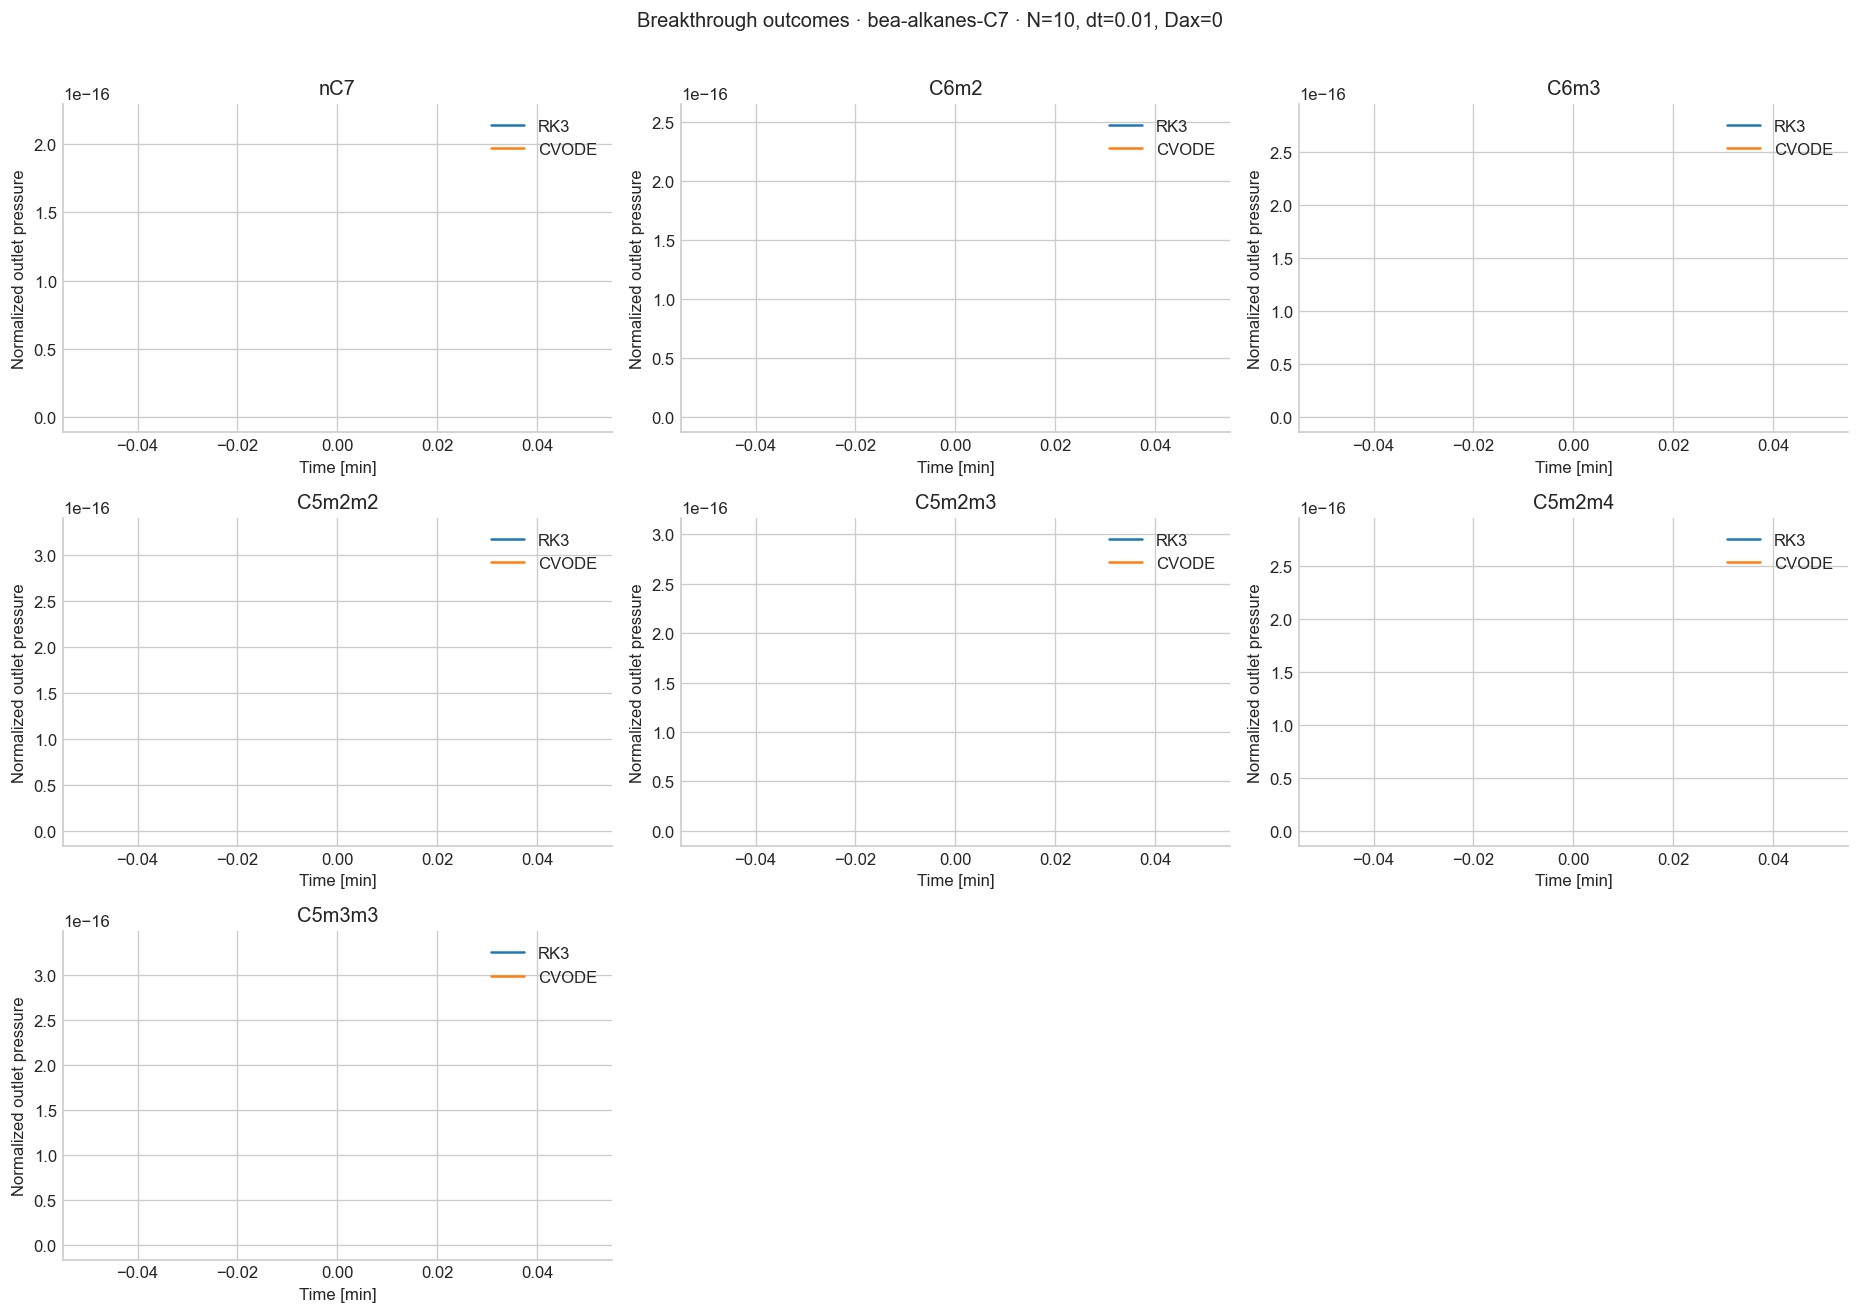

,integrator,component_index,component,t10_minutes,t50_minutes,t90_minutes,last_time_minutes,last_outlet_value
7,cvode,1,nC7,NaN,NaN,NaN,0,2.18338e-16
0,rk3,1,nC7,NaN,NaN,NaN,0,0
8,cvode,2,C6m2,NaN,NaN,NaN,0,2.52858e-16
1,rk3,2,C6m2,NaN,NaN,NaN,0,0
9,cvode,3,C6m3,NaN,NaN,NaN,0,2.81271e-16
2,rk3,3,C6m3,NaN,NaN,NaN,0,0
10,cvode,4,C5m2m2,NaN,NaN,NaN,0,3.24449e-16
3,rk3,4,C5m2m2,NaN,NaN,NaN,0,0
11,cvode,5,C5m2m3,NaN,NaN,NaN,0,3.01622e-16
4,rk3,5,C5m2m3,NaN,NaN,NaN,0,0


In [25]:
selected_curves: dict[
    tuple[str, int], tuple[str, pd.DataFrame]
] = {}
selected_simulation = None

for integrator, directory in selected_directories.items():
    if directory is None:
        print(f"No manifest configuration for {integrator}")
        continue

    relative_directory = directory.relative_to(BENCHMARK_DIR).as_posix()
    status_rows = runs[runs["directory"] == relative_directory]
    status = (
        status_rows["status"].iloc[0]
        if not status_rows.empty
        else "unknown"
    )
    if status != "success" and not ALLOW_INCOMPLETE_CURVES:
        print(
            f"{integrator}: status is {status!r}; skipping incomplete curve"
        )
        continue

    simulation = json.loads(
        (directory / "simulation.json").read_text()
    )
    selected_simulation = simulation
    component_indices = [
        index
        for index, component in enumerate(simulation["Components"])
        if not component.get("CarrierGas", False)
    ]

    for component_index in component_indices:
        try:
            selected_curves[(integrator, component_index)] = (
                load_outlet_curve(directory, component_index)
            )
        except (FileNotFoundError, ValueError) as error:
            print(f"{integrator}, component {component_index}: {error}")

if not selected_curves:
    print(
        "No complete selected curves are available yet. "
        "Rerun after the selected simulations finish."
    )
else:
    available_components = sorted(
        {component for _, component in selected_curves}
    )
    columns = min(3, len(available_components))
    rows_count = math.ceil(len(available_components) / columns)
    fig, axes = plt.subplots(
        rows_count,
        columns,
        figsize=(5.2 * columns, 3.6 * rows_count),
        squeeze=False,
    )
    for axis, component_index in zip(
        axes.flat, available_components
    ):
        for integrator in ("rk3", "cvode"):
            item = selected_curves.get(
                (integrator, component_index)
            )
            if item is None:
                continue
            component_name, curve = item
            axis.plot(
                curve["time_minutes"],
                curve["normalized_outlet_pressure"],
                label=integrator.upper(),
            )
        axis.set_title(component_name)
        axis.set_xlabel("Time [min]")
        axis.set_ylabel("Normalized outlet pressure")
        axis.legend()
    for axis in list(axes.flat)[len(available_components):]:
        axis.set_visible(False)
    fig.suptitle(
        f"Breakthrough outcomes · {SELECTED_CASE} · "
        f"N={SELECTED_GRID_POINTS}, dt={SELECTED_TIME_STEP:g}, "
        f"Dax={SELECTED_DISPERSION:g}",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()

    metric_rows = []
    for (integrator, component_index), (
        component_name,
        curve,
    ) in selected_curves.items():
        metric_rows.append({
            "integrator": integrator,
            "component_index": component_index,
            "component": component_name,
            **outcome_metrics(curve),
        })
    outcome_table = pd.DataFrame(metric_rows)
    display(
        outcome_table.sort_values(
            ["component_index", "integrator"]
        )
    )


In [26]:
comparison_rows = []
component_indices = sorted(
    {
        component
        for integrator, component in selected_curves
        if integrator == "rk3"
        and ("cvode", component) in selected_curves
    }
)

for component_index in component_indices:
    component_name, rk3_curve = selected_curves[
        ("rk3", component_index)
    ]
    _, cvode_curve = selected_curves[
        ("cvode", component_index)
    ]
    rk3_metrics = outcome_metrics(rk3_curve)
    cvode_metrics = outcome_metrics(cvode_curve)
    comparison_rows.append({
        "component_index": component_index,
        "component": component_name,
        **curve_difference(rk3_curve, cvode_curve),
        "rk3_t10_minutes": rk3_metrics["t10_minutes"],
        "cvode_t10_minutes": cvode_metrics["t10_minutes"],
        "delta_t10_minutes": (
            rk3_metrics["t10_minutes"]
            - cvode_metrics["t10_minutes"]
        ),
        "rk3_t50_minutes": rk3_metrics["t50_minutes"],
        "cvode_t50_minutes": cvode_metrics["t50_minutes"],
        "delta_t50_minutes": (
            rk3_metrics["t50_minutes"]
            - cvode_metrics["t50_minutes"]
        ),
        "rk3_t90_minutes": rk3_metrics["t90_minutes"],
        "cvode_t90_minutes": cvode_metrics["t90_minutes"],
        "delta_t90_minutes": (
            rk3_metrics["t90_minutes"]
            - cvode_metrics["t90_minutes"]
        ),
    })

if comparison_rows:
    integrator_outcome_comparison = pd.DataFrame(
        comparison_rows
    )
    display(integrator_outcome_comparison)
else:
    print("No complete RK3/CVODE outcome pairs are available yet.")


,component_index,component,rmse,mean_absolute_error,maximum_absolute_error,overlap_minutes,rk3_t10_minutes,cvode_t10_minutes,delta_t10_minutes,rk3_t50_minutes,cvode_t50_minutes,delta_t50_minutes,rk3_t90_minutes,cvode_t90_minutes,delta_t90_minutes
0,1,nC7,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,C6m2,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,C6m3,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,C5m2m2,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,C5m2m3,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,C5m2m4,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,C5m3m3,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Breakthrough-curve parameter sweep

This section overlays the outcome while varying one matrix parameter. Change SWEEP_PARAMETER to grid_points, time_step, axial_dispersion_coefficient, or integrator. Fixed controls are ignored for whichever parameter is swept.

The default compares the three dispersion coefficients for a completed CVODE point.

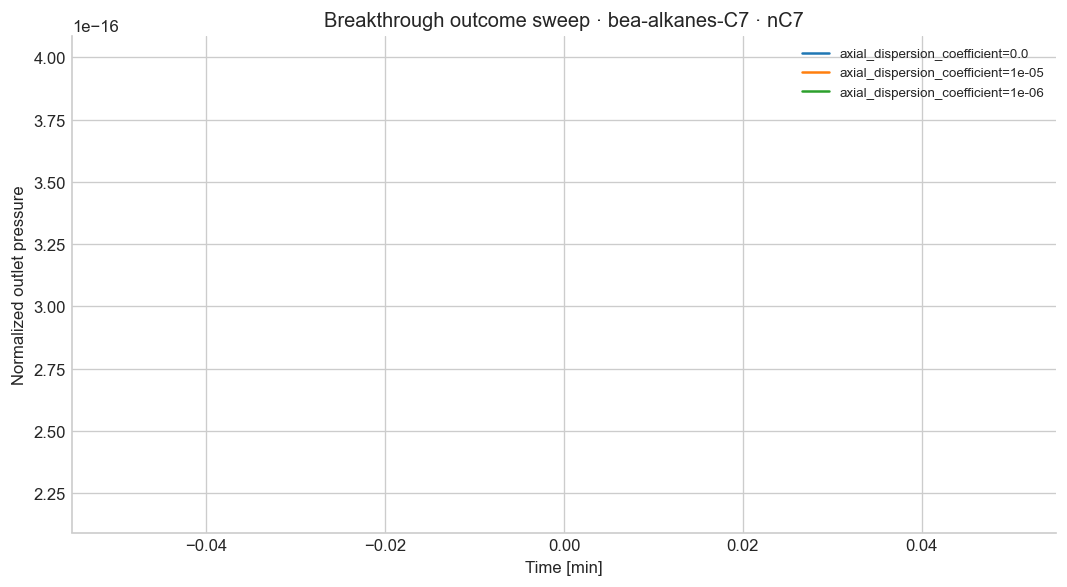

,axial_dispersion_coefficient,component,t10_minutes,t50_minutes,t90_minutes,last_time_minutes,last_outlet_value
0,0,nC7,NaN,NaN,NaN,0,2.18338e-16
2,1e-06,nC7,NaN,NaN,NaN,0,3.34076e-16
1,1e-05,nC7,NaN,NaN,NaN,0,3.99497e-16


In [27]:
SWEEP_CASE = "bea-alkanes-C7"
SWEEP_PARAMETER = "axial_dispersion_coefficient"
SWEEP_COMPONENT_INDEX = 1

SWEEP_FIXED_GRID_POINTS = 10
SWEEP_FIXED_TIME_STEP = 1e-2
SWEEP_FIXED_DISPERSION = 0.0
SWEEP_FIXED_INTEGRATOR = "cvode"
SWEEP_ALLOW_INCOMPLETE = False

valid_sweep_parameters = {
    "grid_points",
    "time_step",
    "axial_dispersion_coefficient",
    "integrator",
}
if SWEEP_PARAMETER not in valid_sweep_parameters:
    raise ValueError(
        f"SWEEP_PARAMETER must be one of {valid_sweep_parameters}"
    )

sweep_mask = manifest["base_case"].eq(SWEEP_CASE)
fixed_filters = {
    "grid_points": SWEEP_FIXED_GRID_POINTS,
    "time_step": SWEEP_FIXED_TIME_STEP,
    "axial_dispersion_coefficient": SWEEP_FIXED_DISPERSION,
    "integrator": SWEEP_FIXED_INTEGRATOR,
}
for parameter, value in fixed_filters.items():
    if parameter == SWEEP_PARAMETER:
        continue
    if parameter in {
        "time_step",
        "axial_dispersion_coefficient",
    }:
        sweep_mask &= np.isclose(manifest[parameter], value)
    else:
        sweep_mask &= manifest[parameter].eq(value)

sweep_rows = manifest[sweep_mask].copy()
sweep_rows = sweep_rows.merge(
    runs[["directory", "status"]],
    on="directory",
    how="left",
)
if not SWEEP_ALLOW_INCOMPLETE:
    sweep_rows = sweep_rows[sweep_rows["status"] == "success"]

sweep_curves = []
for row in sweep_rows.itertuples(index=False):
    directory = BENCHMARK_DIR / row.directory
    try:
        component_name, curve = load_outlet_curve(
            directory, SWEEP_COMPONENT_INDEX
        )
    except (FileNotFoundError, ValueError) as error:
        print(f"{row.directory}: {error}")
        continue
    sweep_curves.append((
        getattr(row, SWEEP_PARAMETER),
        component_name,
        curve,
    ))

if not sweep_curves:
    print(
        "No completed curves match this sweep. "
        "Adjust the controls or rerun after more simulations finish."
    )
else:
    fig, axis = plt.subplots(figsize=(9, 5))
    sweep_metric_rows = []
    for value, component_name, curve in sorted(
        sweep_curves, key=lambda item: str(item[0])
    ):
        axis.plot(
            curve["time_minutes"],
            curve["normalized_outlet_pressure"],
            label=f"{SWEEP_PARAMETER}={value}",
        )
        sweep_metric_rows.append({
            SWEEP_PARAMETER: value,
            "component": component_name,
            **outcome_metrics(curve),
        })
    axis.set_xlabel("Time [min]")
    axis.set_ylabel("Normalized outlet pressure")
    axis.set_title(
        f"Breakthrough outcome sweep · {SWEEP_CASE} · "
        f"{component_name}"
    )
    axis.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
    display(
        pd.DataFrame(sweep_metric_rows)
        .sort_values(SWEEP_PARAMETER)
    )


## Optional full convergence scan

This scan compares every completed RK3/CVODE curve at one case, dispersion coefficient and component against a chosen fine-grid/fine-timestep reference curve. It may need to read many large output files, so it is disabled by default. Set RUN_FULL_CONVERGENCE_SCAN to True when the relevant array is complete.

In [28]:
RUN_FULL_CONVERGENCE_SCAN = False

CONVERGENCE_CASE = "bea-alkanes-C7"
CONVERGENCE_DISPERSION = 0.0
CONVERGENCE_COMPONENT_INDEX = 1
REFERENCE_INTEGRATOR = "cvode"
REFERENCE_GRID_POINTS = 200
REFERENCE_TIME_STEP = 1e-5

if not RUN_FULL_CONVERGENCE_SCAN:
    print(
        "Full convergence scan disabled. "
        "Set RUN_FULL_CONVERGENCE_SCAN = True to run it."
    )
else:
    reference_directory = manifest_directory(
        CONVERGENCE_CASE,
        REFERENCE_GRID_POINTS,
        REFERENCE_TIME_STEP,
        CONVERGENCE_DISPERSION,
        REFERENCE_INTEGRATOR,
    )
    if reference_directory is None:
        raise ValueError("Reference configuration is absent")
    reference_name, reference_curve = load_outlet_curve(
        reference_directory,
        CONVERGENCE_COMPONENT_INDEX,
    )

    scan_mask = (
        runs["base_case"].eq(CONVERGENCE_CASE)
        & np.isclose(
            runs["axial_dispersion_coefficient"],
            CONVERGENCE_DISPERSION,
        )
        & runs["integrator"].isin(["rk3", "cvode"])
        & runs["status"].eq("success")
    )
    convergence_rows = []
    for row in runs[scan_mask].itertuples(index=False):
        directory = BENCHMARK_DIR / row.directory
        try:
            _, curve = load_outlet_curve(
                directory,
                CONVERGENCE_COMPONENT_INDEX,
            )
        except (FileNotFoundError, ValueError) as error:
            print(f"{row.directory}: {error}")
            continue
        metrics = curve_difference(curve, reference_curve)
        convergence_rows.append({
            "integrator": row.integrator,
            "grid_points": row.grid_points,
            "time_step": row.time_step,
            **metrics,
        })

    convergence = pd.DataFrame(convergence_rows)
    display(
        convergence.sort_values(
            ["integrator", "grid_points", "time_step"]
        )
    )

    if not convergence.empty:
        integrators = list(
            convergence["integrator"].drop_duplicates()
        )
        fig, axes = plt.subplots(
            1,
            len(integrators),
            figsize=(6 * len(integrators), 4.5),
            squeeze=False,
        )
        for axis, integrator in zip(
            axes.flat, integrators
        ):
            subset = convergence[
                convergence["integrator"] == integrator
            ]
            for grid_points, values in subset.groupby(
                "grid_points"
            ):
                values = values.sort_values("time_step")
                axis.plot(
                    values["time_step"],
                    values["rmse"],
                    marker="o",
                    label=f"N={grid_points}",
                )
            axis.set_xscale("log")
            axis.set_yscale("log")
            axis.set_xlabel("Time step [s]")
            axis.set_ylabel("Curve RMSE")
            axis.set_title(
                f"{integrator} vs reference · {reference_name}"
            )
            axis.legend(fontsize=8)
        fig.tight_layout()
        plt.show()


Full convergence scan disabled. Set RUN_FULL_CONVERGENCE_SCAN = True to run it.


## Interpretation checklist

- Compare only exact parameter pairs when discussing integrator speed.
- Check failures before interpreting missing or unusually fast runs.
- Use breakthrough-time shifts and full-curve errors alongside timing; speed alone does not establish numerical equivalence.
- Inspect whether automatic stopping produced materially different final simulated times.
- Use the parameter sweep to expose sensitivity to grid, timestep and dispersion.
- Treat SIRK3 as configuration coverage only until the implementation is runnable.

## Single-bed versus one-adsorbent multibed benchmark

The completed 120-setting matrix crosses 2–6 total fluid components, energy balance off/on, physisorption/direct chemisorption/surface-pore-transport chemisorption, and IAST/SIAST/SEI/SPI. The performance run contains separate single-bed and multibed timings plus an equality benchmark; the correctness run independently writes every final-state comparison.


In [29]:
MULTIBED_DIR = BENCHMARK_DIR / "multibed"
PERFORMANCE_PATH = MULTIBED_DIR / "performance_results.json"
CORRECTNESS_PATH = MULTIBED_DIR / "simulations" / "summary.csv"

with PERFORMANCE_PATH.open(encoding="utf-8") as stream:
    benchmark_document = json.load(stream)

def parse_benchmark_label(label: str) -> dict[str, str]:
    return dict(part.split("=", 1) for part in label.split("/") if "=" in part)

def implementation_name(name: str) -> str | None:
    if name.startswith("BM_MultibedWithOneAdsorbent/"):
        return "Multibed"
    if name.startswith("BM_SingleBed/"):
        return "Single bed"
    return None

unit_to_ms = {"ns": 1e-6, "us": 1e-3, "ms": 1.0, "s": 1e3}
performance_rows = []
for record in benchmark_document["benchmarks"]:
    implementation = implementation_name(record["name"])
    if implementation is None:
        continue
    dimensions = parse_benchmark_label(record.get("label", ""))
    performance_rows.append({
        "setting_index": int(re.search(r"setting:(\d+)", record["name"]).group(1)),
        "components": int(dimensions["components"]),
        "energy": dimensions["energy"],
        "workload": dimensions["workload"],
        "method": dimensions["method"],
        "implementation": implementation,
        "runtime_ms": record["real_time"] * unit_to_ms[record["time_unit"]],
        "cpu_time_ms": record["cpu_time"] * unit_to_ms[record["time_unit"]],
        "iterations": record["iterations"],
    })
performance = pd.DataFrame(performance_rows)

keys = ["setting_index", "components", "energy", "workload", "method"]
timings = (
    performance.pivot(index=keys, columns="implementation", values="runtime_ms")
    .rename(columns={"Single bed": "single_bed_ms", "Multibed": "multibed_ms"})
    .reset_index()
)
timings["multibed_over_single"] = timings["multibed_ms"] / timings["single_bed_ms"]

correctness = pd.read_csv(CORRECTNESS_PATH).rename(
    columns={"component_count": "components", "energy_balance": "energy"}
)
correctness["setting_index"] = np.arange(len(correctness))
correctness["results_equal"] = correctness["results_equal"].astype(bool)

result_columns = [
    "setting_index", "components", "energy", "workload", "method",
    "single_bed_ms", "multibed_ms", "multibed_over_single",
    "max_state_abs", "max_state_rel", "max_pressure_abs",
    "max_pressure_rel", "max_velocity_abs", "max_velocity_rel",
    "results_equal",
]
all_multibed_results = timings.merge(
    correctness, on=["setting_index", "components", "energy", "workload", "method"],
    validate="one_to_one",
)[result_columns].sort_values("setting_index").reset_index(drop=True)

expected_settings = 5 * 2 * 3 * 4
assert len(all_multibed_results) == expected_settings
assert len(performance) == 2 * expected_settings

display(Markdown(
    f"**Coverage:** {len(all_multibed_results)}/{expected_settings} settings; "
    f"**agreement:** {int(all_multibed_results['results_equal'].sum())}/{expected_settings}; "
    f"**largest state error:** {all_multibed_results['max_state_abs'].max():.3e}; "
    f"**largest pressure error:** {all_multibed_results['max_pressure_abs'].max():.3e}; "
    f"**largest velocity error:** {all_multibed_results['max_velocity_abs'].max():.3e}."
))
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(all_multibed_results.style.format({
        "single_bed_ms": "{:.3f}",
        "multibed_ms": "{:.3f}",
        "multibed_over_single": "{:.3f}",
        "max_state_abs": "{:.3e}",
        "max_state_rel": "{:.3e}",
        "max_pressure_abs": "{:.3e}",
        "max_pressure_rel": "{:.3e}",
        "max_velocity_abs": "{:.3e}",
        "max_velocity_rel": "{:.3e}",
    }))


**Coverage:** 120/120 settings; **agreement:** 120/120; **largest state error:** 1.478e-12; **largest pressure error:** 4.657e-10; **largest velocity error:** 1.388e-16.

,setting_index,components,energy,workload,method,single_bed_ms,multibed_ms,multibed_over_single,max_state_abs,max_state_rel,max_pressure_abs,max_pressure_rel,max_velocity_abs,max_velocity_rel,results_equal
0,0,2,off,physisorption,IAST,1.370,1.818,1.327,7.105e-15,2.372e-16,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True
1,1,2,off,physisorption,SIAST,1.311,1.753,1.338,7.105e-15,2.372e-16,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True
2,2,2,off,physisorption,SEI,1.316,1.782,1.354,7.105e-15,2.372e-16,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True
3,3,2,off,physisorption,SPI,1.301,1.806,1.388,7.105e-15,2.372e-16,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True
4,4,2,off,chemisorption-direct,IAST,2.039,2.547,1.249,3.411e-13,4.844e-16,0.000e+00,0.000e+00,2.776e-17,2.776e-17,True
5,5,2,off,chemisorption-direct,SIAST,1.995,2.374,1.190,3.411e-13,4.844e-16,0.000e+00,0.000e+00,2.776e-17,2.776e-17,True
6,6,2,off,chemisorption-direct,SEI,1.987,2.363,1.189,3.411e-13,4.844e-16,0.000e+00,0.000e+00,2.776e-17,2.776e-17,True
7,7,2,off,chemisorption-direct,SPI,1.961,2.400,1.224,3.411e-13,4.844e-16,0.000e+00,0.000e+00,2.776e-17,2.776e-17,True
8,8,2,off,chemisorption-transport,IAST,2.112,2.565,1.215,3.469e-18,3.469e-18,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True
9,9,2,off,chemisorption-transport,SIAST,2.064,2.534,1.228,3.469e-18,3.469e-18,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True


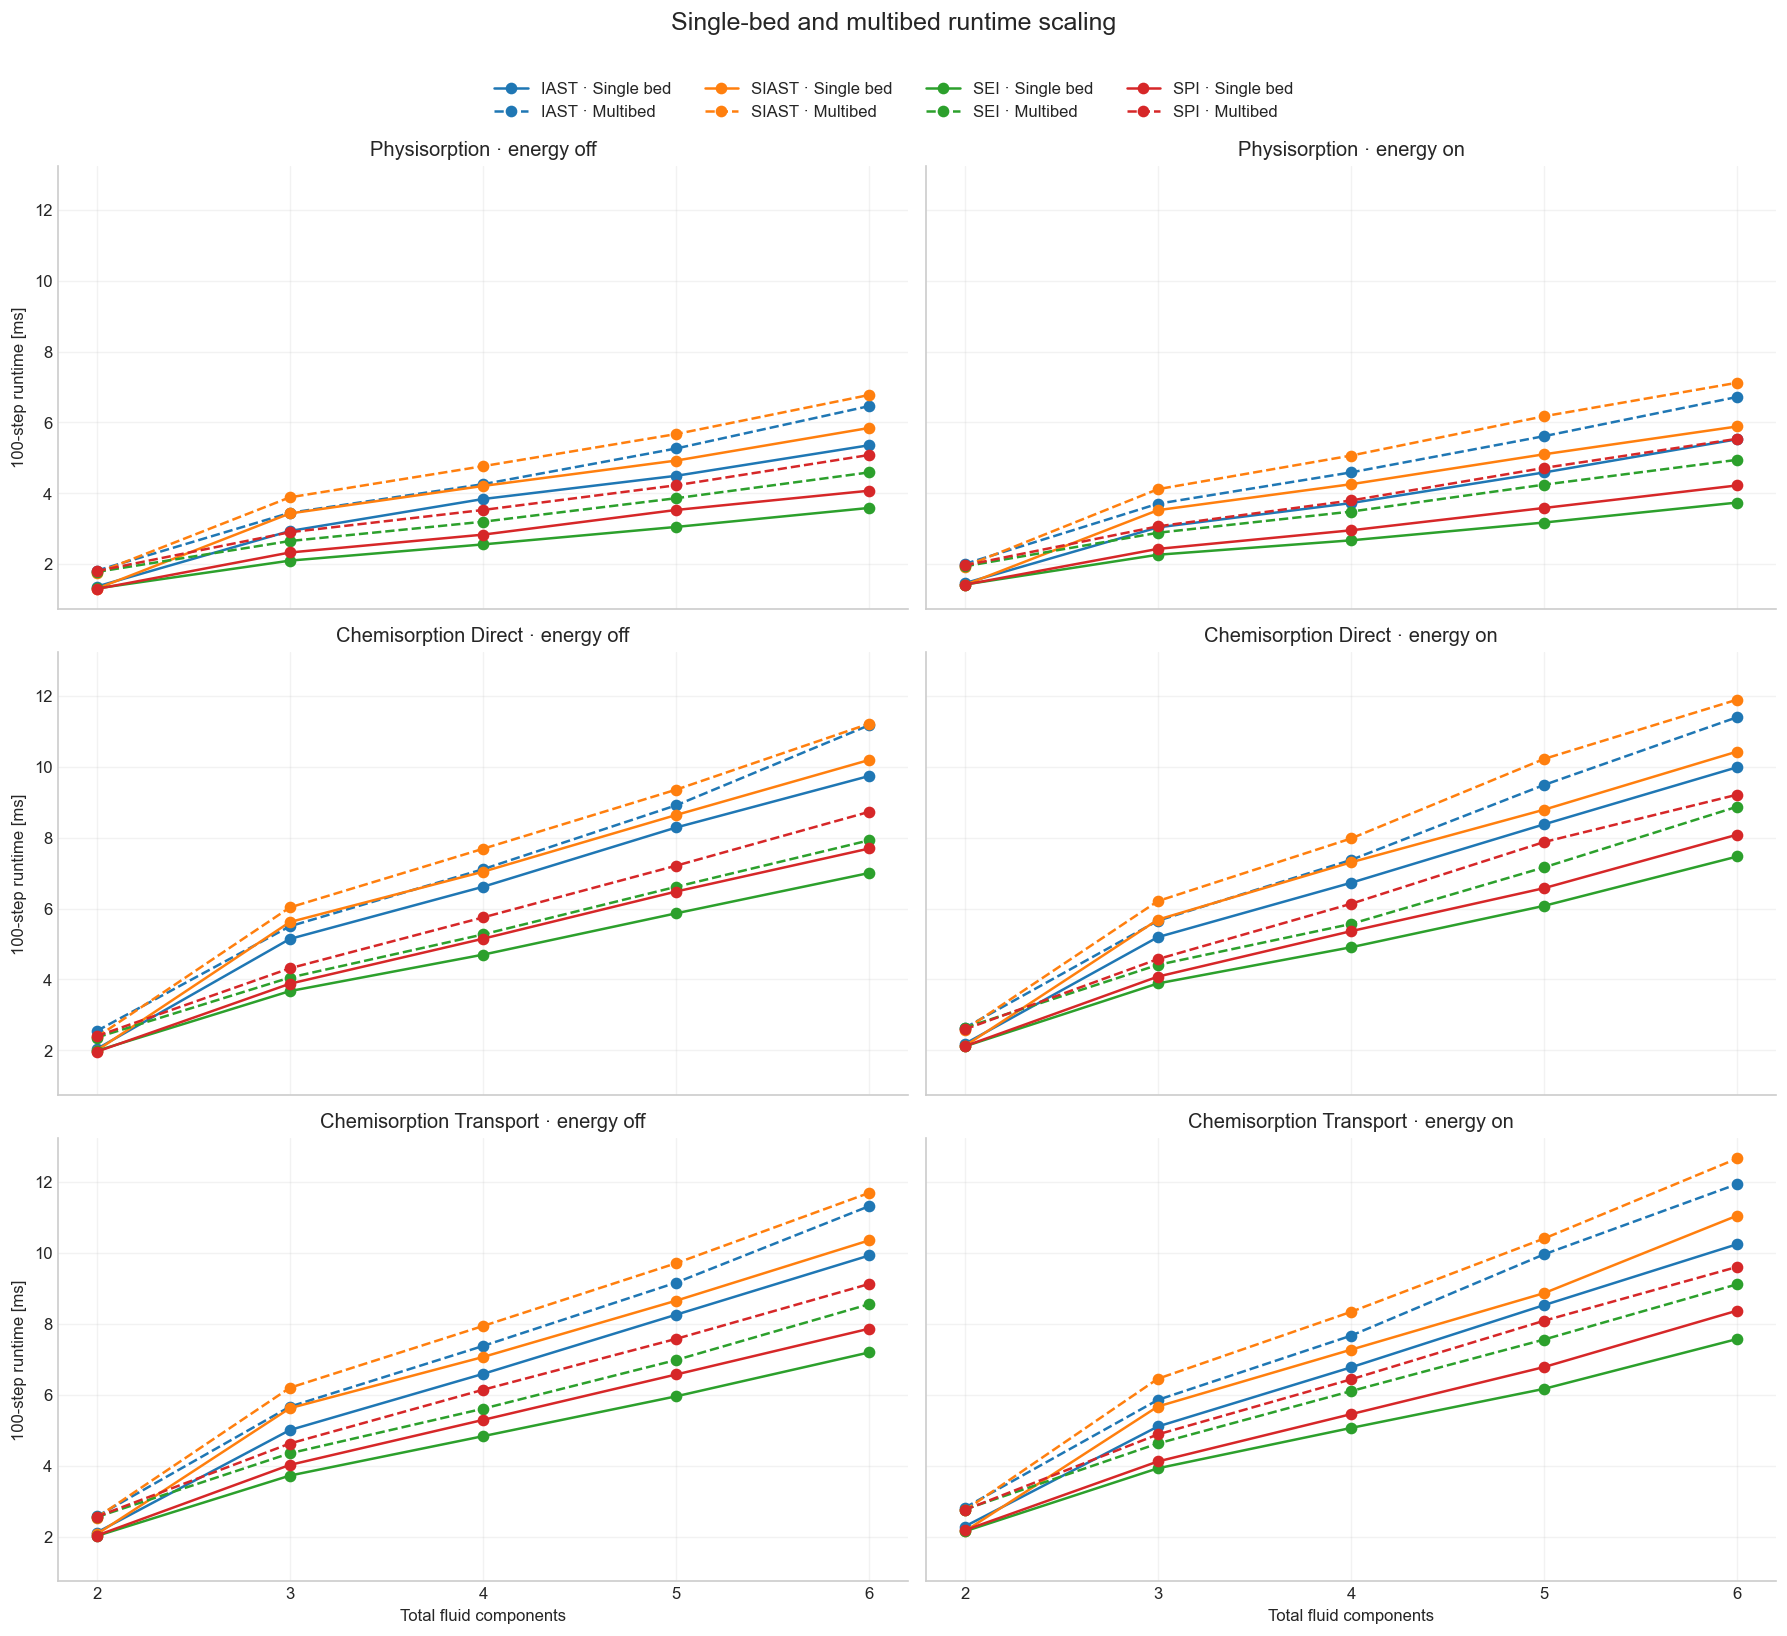

In [30]:
method_order = ["IAST", "SIAST", "SEI", "SPI"]
workload_order = ["physisorption", "chemisorption-direct", "chemisorption-transport"]
energy_order = ["off", "on"]
method_colors = dict(zip(method_order, plt.cm.tab10.colors[:4]))
implementation_styles = {"Single bed": "-", "Multibed": "--"}

fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True, sharey=True)
for row, workload in enumerate(workload_order):
    for column, energy in enumerate(energy_order):
        axis = axes[row, column]
        subset = performance[(performance["workload"] == workload) & (performance["energy"] == energy)]
        for method in method_order:
            for implementation, line_style in implementation_styles.items():
                values = subset[(subset["method"] == method) & (subset["implementation"] == implementation)].sort_values("components")
                axis.plot(
                    values["components"], values["runtime_ms"], marker="o",
                    color=method_colors[method], linestyle=line_style,
                    label=f"{method} · {implementation}",
                )
        axis.set_title(f"{workload.replace('-', ' ').title()} · energy {energy}")
        axis.set_xticks(range(2, 7))
        axis.grid(alpha=0.25)
        if row == 2:
            axis.set_xlabel("Total fluid components")
        if column == 0:
            axis.set_ylabel("100-step runtime [ms]")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Single-bed and multibed runtime scaling", y=1.045, fontsize=15)
fig.tight_layout()
plt.show()


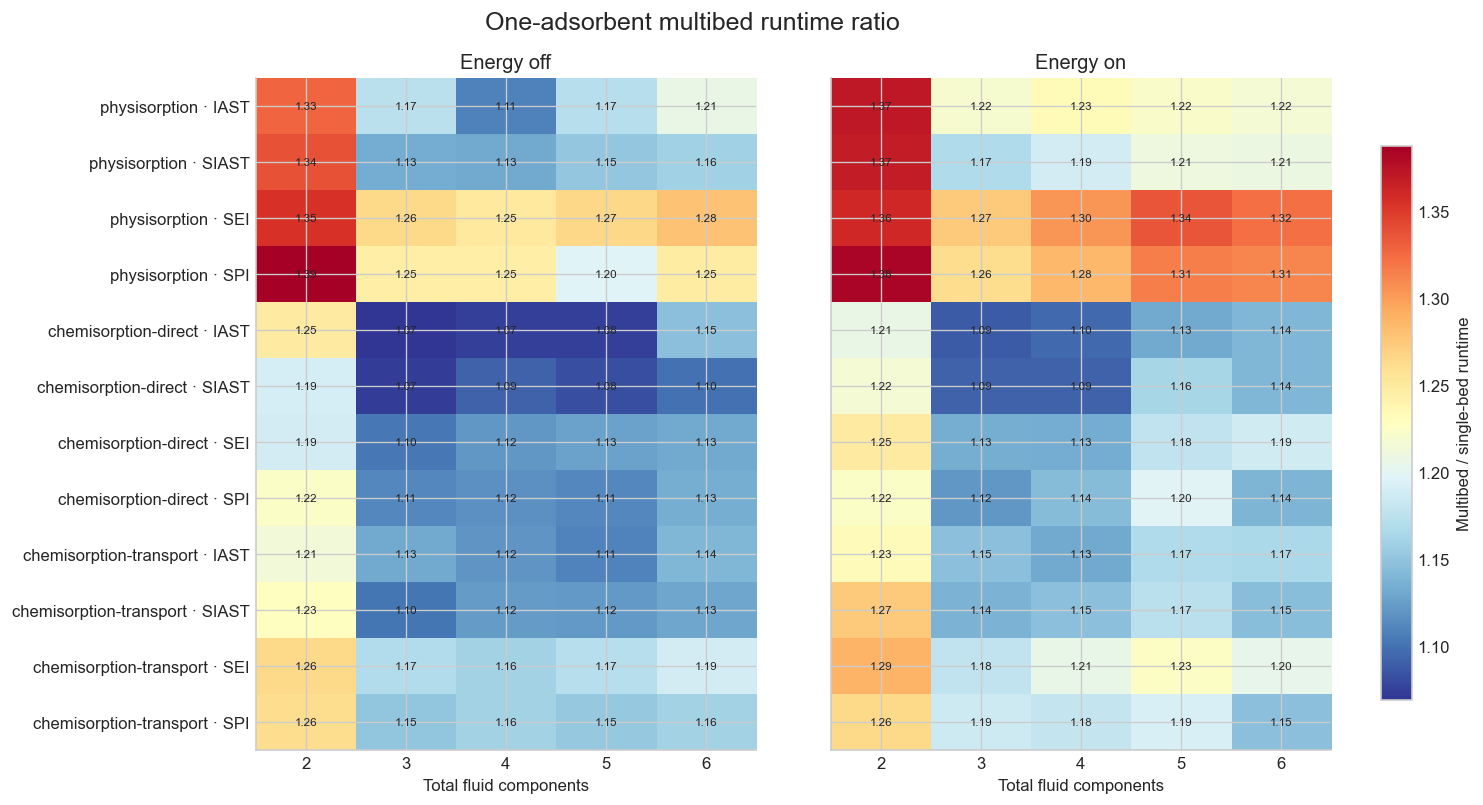

### Aggregate runtime by implementation, workload, and method

### Twelve largest final-state differences

,components,energy,workload,method,max_state_abs,max_state_rel,results_equal
112,6,on,chemisorption-direct,IAST,1.478e-12,1.524e-15,True
103,6,off,chemisorption-direct,SPI,1.251e-12,1.248e-15,True
119,6,on,chemisorption-transport,SPI,1.137e-12,1.211e-15,True
101,6,off,chemisorption-direct,SIAST,9.095e-13,9.074e-16,True
113,6,on,chemisorption-direct,SIAST,9.095e-13,9.074e-16,True
107,6,off,chemisorption-transport,SPI,7.958e-13,7.940e-16,True
115,6,on,chemisorption-direct,SPI,7.958e-13,7.940e-16,True
98,6,off,physisorption,SEI,6.821e-13,9.389e-16,True
116,6,on,chemisorption-transport,IAST,6.821e-13,7.367e-16,True
81,5,off,chemisorption-transport,SIAST,5.684e-13,1.243e-15,True


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
ratio_min = all_multibed_results["multibed_over_single"].min()
ratio_max = all_multibed_results["multibed_over_single"].max()
for axis, energy in zip(axes, energy_order):
    matrix = (
        all_multibed_results[all_multibed_results["energy"] == energy]
        .assign(row=lambda frame: frame["workload"] + " · " + frame["method"])
        .pivot(index="row", columns="components", values="multibed_over_single")
        .reindex([f"{workload} · {method}" for workload in workload_order for method in method_order])
    )
    image = axis.imshow(matrix, aspect="auto", cmap="RdYlBu_r", vmin=ratio_min, vmax=ratio_max)
    axis.set_title(f"Energy {energy}")
    axis.set_xticks(range(len(matrix.columns)), matrix.columns)
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set_xlabel("Total fluid components")
    for y in range(matrix.shape[0]):
        for x in range(matrix.shape[1]):
            axis.text(x, y, f"{matrix.iloc[y, x]:.2f}", ha="center", va="center", fontsize=7)
colorbar_axis = fig.add_axes([0.91, 0.16, 0.018, 0.66])
fig.colorbar(image, cax=colorbar_axis, label="Multibed / single-bed runtime")
fig.suptitle("One-adsorbent multibed runtime ratio", fontsize=15)
fig.subplots_adjust(left=0.24, right=0.88, top=0.90, bottom=0.10, wspace=0.15)
plt.show()

aggregate_runtime = (
    performance.groupby(["implementation", "workload", "method"], observed=True)["runtime_ms"]
    .agg(["mean", "min", "max"])
    .rename(columns={"mean": "mean_ms", "min": "min_ms", "max": "max_ms"})
)
worst_errors = all_multibed_results.nlargest(12, "max_state_abs")[
    ["components", "energy", "workload", "method", "max_state_abs", "max_state_rel", "results_equal"]
]
display(Markdown("### Aggregate runtime by implementation, workload, and method"))
display(aggregate_runtime.style.format("{:.3f}"))
display(Markdown("### Twelve largest final-state differences"))
display(worst_errors.style.format({"max_state_abs": "{:.3e}", "max_state_rel": "{:.3e}"}))


## Requested CVODE/RK3 and Marx method figures

These figures use three repeated wall-time measurements per configuration and a common 0.1-second physical horizon. The grid sweep uses $N_{grid}=[10,20,100]$ at the default adsorbing-component count; the component sweep uses $n_{comp}=[2,4,6]$ for BEA and $[1,2,3]$ for Marx at $N_{grid}=100$. Carrier gas is excluded from $n_{comp}$. BEA uses $\Delta t=10^{-5}$–$10^{-2}$ s; the stiffer Marx model uses its paired RK3-stable range $10^{-6}$–$10^{-3}$ s.

Panel (d) reports the maximum absolute CVODE–RK3 difference over every component mole fraction and every grid position at the matched final output time. The Marx-only method matrix compares IAST/SIAST/SEI/SPI across RK3/CVODE, energy off/on, and transported chemisorption off/on. For that four-method comparison only, the Marx Sips sites are consistently projected to their single-site Langmuir limit because SEI requires that common isotherm form.

In [32]:
import sys

FIGURE_DIR = BENCHMARK_DIR / "figures"
if str(FIGURE_DIR) not in sys.path:
    sys.path.insert(0, str(FIGURE_DIR))

from plot_results import load_figure_data, make_cvode_rk3_figure, make_method_bar_figure

figure_timing, figure_errors = load_figure_data(FIGURE_DIR)
figure_coverage = (
    figure_timing.groupby("suite", observed=True)
    .agg(configurations=("directory", "size"), min_repetitions=("successful_repetitions", "min"))
)
display(figure_coverage)
print(f"Paired mole-fraction error rows: {len(figure_errors)}")


,configurations,min_repetitions
suite,,
cvode-rk3,154,3
methods,32,3


Paired mole-fraction error rows: 77


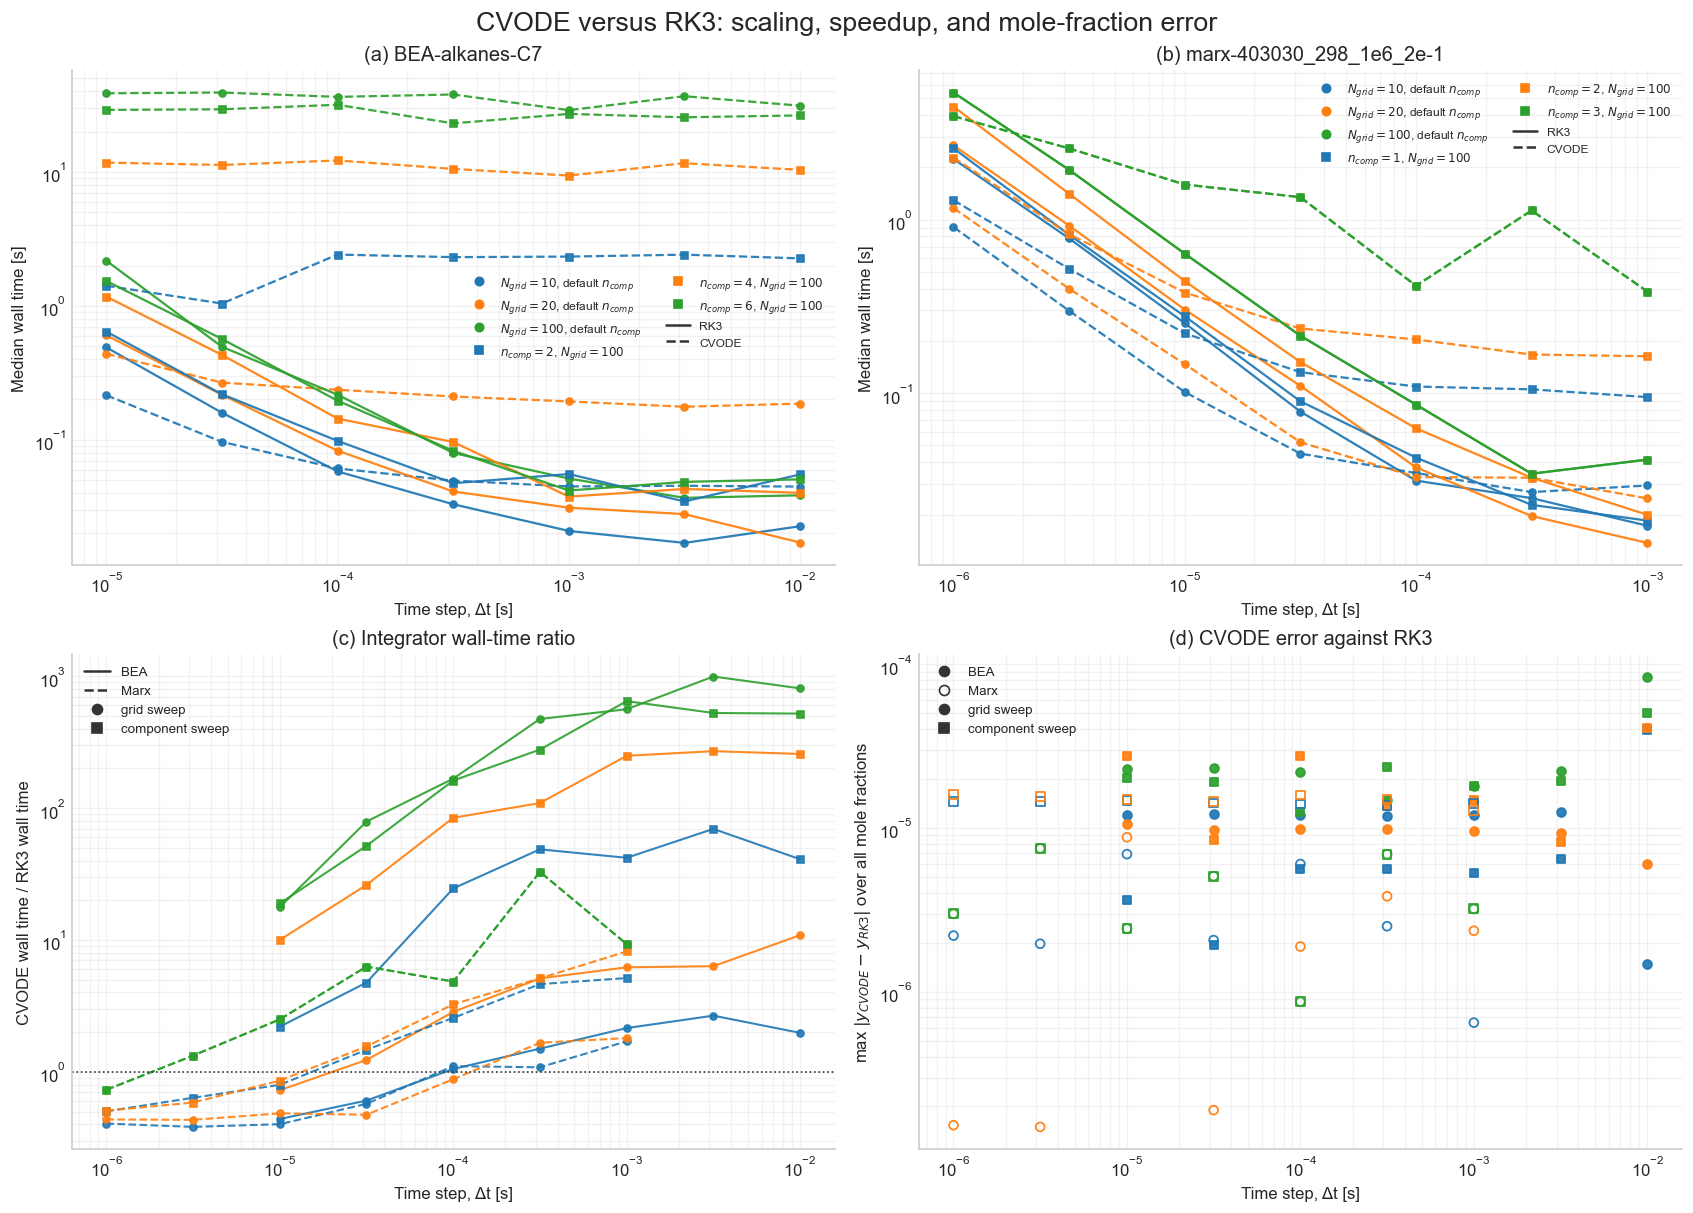

In [33]:
cvode_rk3_figure, cvode_rk3_axes = make_cvode_rk3_figure(figure_timing, figure_errors)
plt.show()


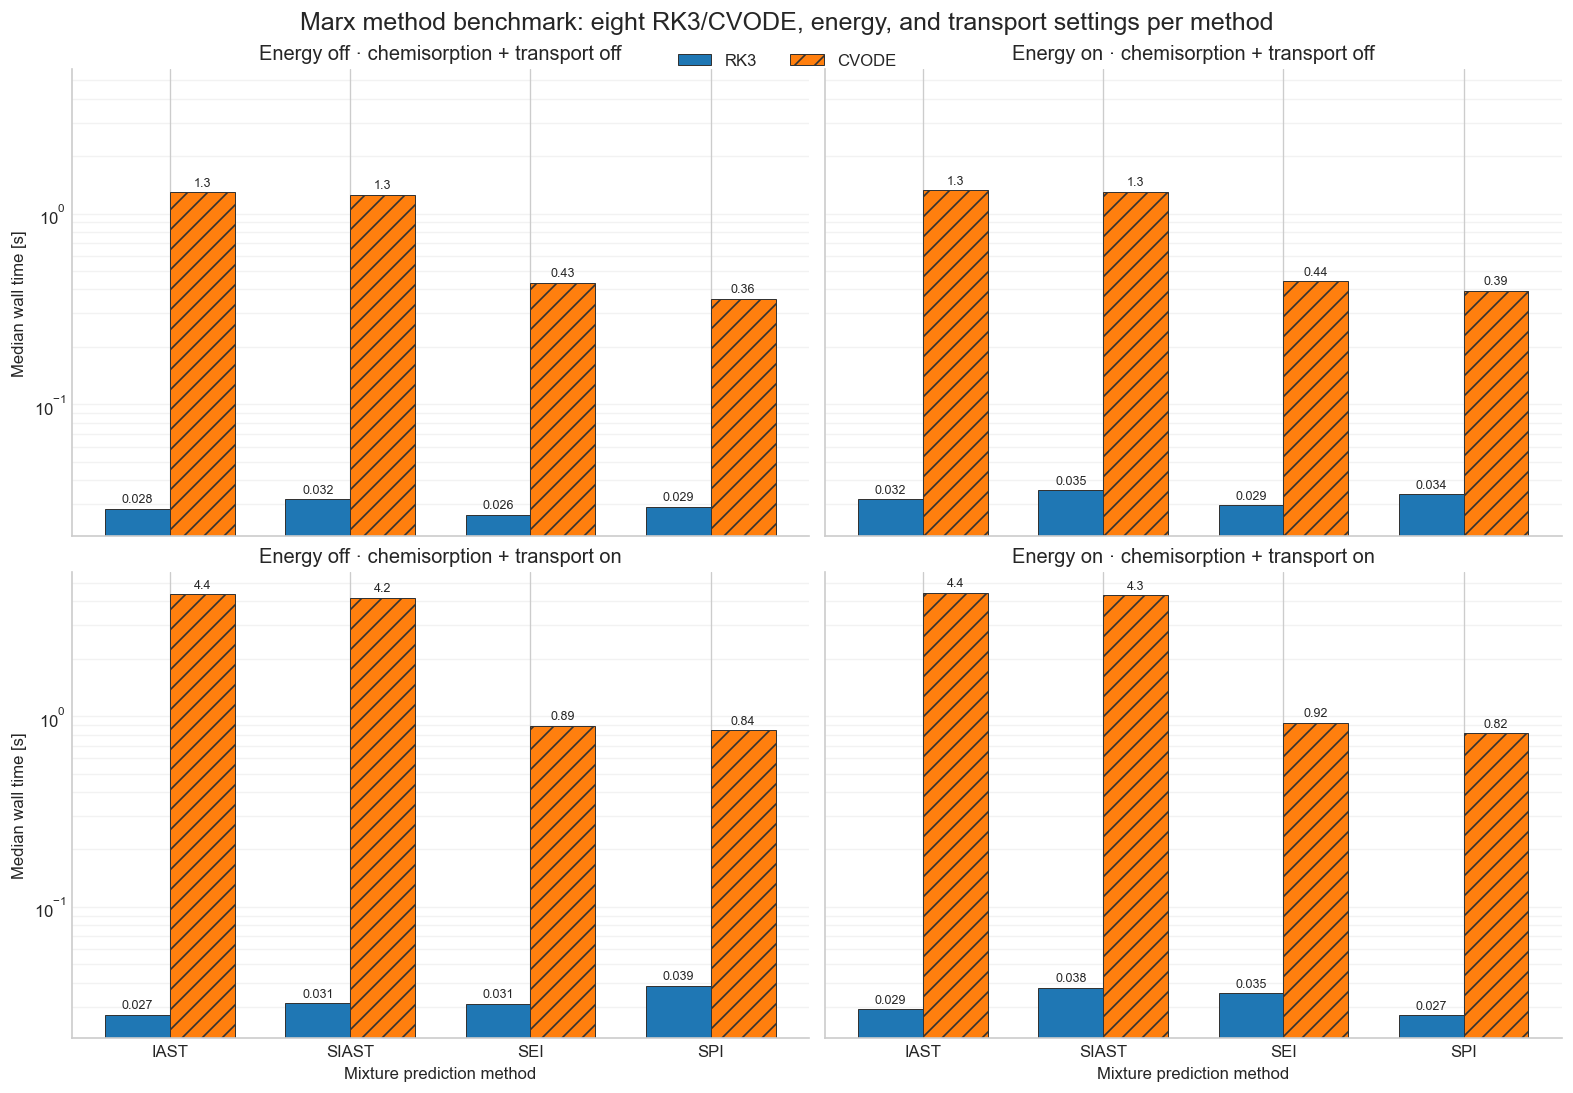

In [17]:
method_bar_figure, method_bar_axes = make_method_bar_figure(figure_timing)
plt.show()
